Training on 455 samples, testing on 114...

--- Logistic Regression ---
Accuracy: 96.49%
Intercept (theta_0): -0.2430
Top 3 features by weight:
  texture_worst: 1.4341
  radius_se: 1.2333
  symmetry_worst: 1.0613

--- GDA (LDA) ---
Accuracy: 96.49%
Priors (phi): B=0.6264, M=0.3736
Mean (radius_mean): B=-0.5624, M=0.9428

--- Naive Bayes ---
Accuracy: 92.11%
Priors: B=0.6264, M=0.3736
Variance (radius_mean): B=0.2477, M=0.8422

Done! Check the 'results' folder for the confusion matrices plot.


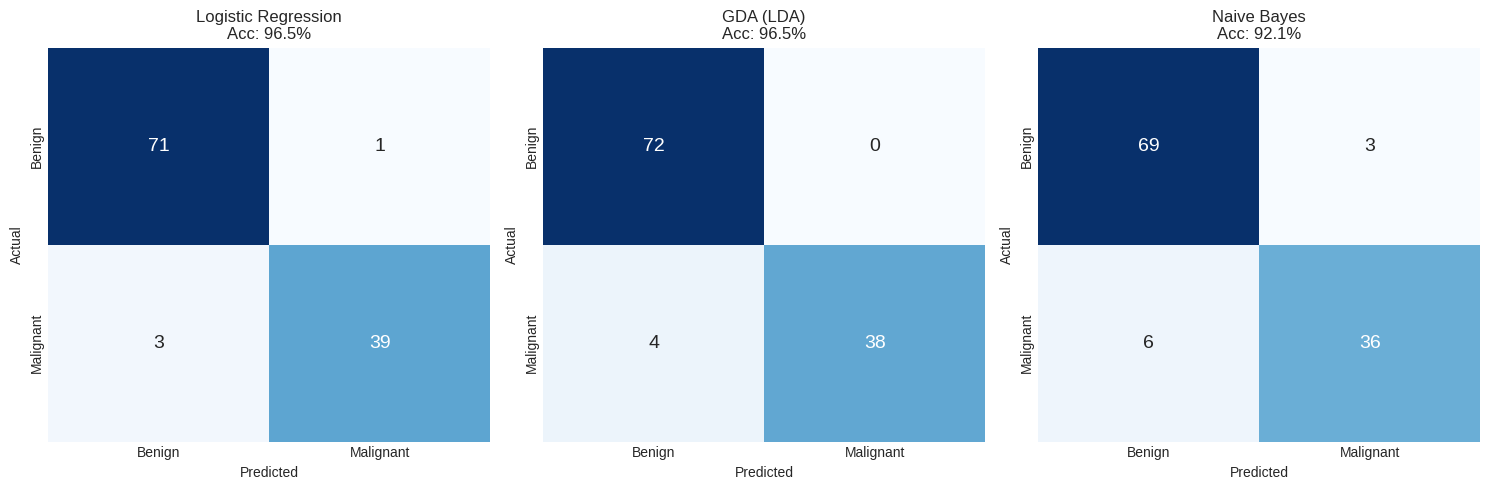

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Create output folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# Load and clean data
try:
    df = pd.read_csv('data.csv')
except FileNotFoundError:
    print("Error: data.csv not found. Make sure it's in the same folder as this script.")
    exit()

# Drop ID and that weird empty column pandas sometimes picks up
df.drop(columns=['id', 'Unnamed: 32'], errors='ignore', inplace=True)

X = df.drop(columns=['diagnosis'])
features = X.columns.tolist()

# Encode labels: Benign=0, Malignant=1
y = LabelEncoder().fit_transform(df['diagnosis'])

# Split and scale (stratify to keep the B/M ratio balanced)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {len(X_train)} samples, testing on {len(X_test)}...\n")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "GDA (LDA)": LinearDiscriminantAnalysis(),
    "Naive Bayes": GaussianNB()
}

# Setup plot for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict and get accuracy
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)

    print(f"--- {name} ---")
    print(f"Accuracy: {acc * 100:.2f}%")

    # Extract and print the learned math parameters
    if name == "Logistic Regression":
        print(f"Intercept (theta_0): {model.intercept_[0]:.4f}")
        weights = model.coef_[0]
        # Get indices of the 3 largest weights
        top_idx = np.argsort(np.abs(weights))[-3:][::-1]
        print("Top 3 features by weight:")
        for i in top_idx:
            print(f"  {features[i]}: {weights[i]:.4f}")

    elif name == "GDA (LDA)":
        print(f"Priors (phi): B={model.priors_[0]:.4f}, M={model.priors_[1]:.4f}")
        print(f"Mean (radius_mean): B={model.means_[0][0]:.4f}, M={model.means_[1][0]:.4f}")

    elif name == "Naive Bayes":
        print(f"Priors: B={model.class_prior_[0]:.4f}, M={model.class_prior_[1]:.4f}")
        print(f"Variance (radius_mean): B={model.var_[0][0]:.4f}, M={model.var_[1][0]:.4f}")

    print() # Just for spacing in the terminal

    # Plot confusion matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 14})
    ax.set_title(f"{name}\nAcc: {acc*100:.1f}%", fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(['Benign', 'Malignant'])
    ax.set_yticklabels(['Benign', 'Malignant'])

plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=300)
print("Done! Check the 'results' folder for the confusion matrices plot.")